# RQ7 — Practical Usefulness and Final Recommendation
**Research Question:** Which model offers the best trade-off between performance, interpretability, robustness, and deployment cost?

Includes: decision matrix, radar chart, and fairness check across demographic groups.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier

df = pd.read_csv('/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['loan_paid_back'].value_counts()}")


Shape: (20000, 22)
Target distribution:
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64


In [2]:
cat_cols = ['gender','marital_status','education_level',
            'employment_status','loan_purpose','grade_subgrade']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop('loan_paid_back', axis=1)
y = df_enc['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (16000, 21) | Test: (4000, 21)


In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [4]:
# ── Train three candidate models with full pipeline ───────────────
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train_sc, y_train)

lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                     random_state=42, eval_metric='logloss', verbosity=0)

lr.fit(X_train_sc, y_train)
rf.fit(X_tr_sm, y_tr_sm)
xgb.fit(X_tr_sm, y_tr_sm)

final = []
for name, model in [('Logistic Reg.', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    yp  = model.predict(X_test_sc)
    ypr = model.predict_proba(X_test_sc)[:,1]
    final.append({'Model': name,
        'Accuracy': round(accuracy_score(y_test,yp),3),
        'F1-Score': round(f1_score(y_test,yp),3),
        'Recall':   round(recall_score(y_test,yp),3),
        'AUC':      round(roc_auc_score(y_test,ypr),3)})
    print(f"{name}: F1={final[-1]['F1-Score']} | AUC={final[-1]['AUC']}")

print("\n=== Final model scores ===")
print(pd.DataFrame(final).to_string(index=False))


Logistic Reg.: F1=0.932 | AUC=0.852
Random Forest: F1=0.94 | AUC=0.871
XGBoost: F1=0.942 | AUC=0.882

=== Final model scores ===
        Model  Accuracy  F1-Score  Recall   AUC
Logistic Reg.     0.888     0.932   0.968 0.852
Random Forest     0.898     0.940   0.986 0.871
      XGBoost     0.903     0.942   0.989 0.882


In [5]:
# ── Decision matrix (Table VII) ──────────────────────────────────
decision = {
    'Criterion':          ['Pred. performance','Default Recall','Robustness (CV std)',
                           'Interpretability','Deployment suitability','Regulatory auditability'],
    'Logistic Reg.':      ['Medium','Low','±0.021','Very High','High','High'],
    'Random Forest':      ['High','Good','±0.011','Medium','High','Medium'],
    'XGBoost':            ['Best','Best','±0.009','Medium-Low','Medium','Low'],
    'Recommended':        ['XGBoost','XGBoost','XGBoost','Logistic Reg.','Random Forest','Logistic Reg.'],
}
print("=== TABLE VII: Decision Matrix ===")
print(pd.DataFrame(decision).to_string(index=False))


=== TABLE VII: Decision Matrix ===
              Criterion Logistic Reg. Random Forest    XGBoost   Recommended
      Pred. performance        Medium          High       Best       XGBoost
         Default Recall           Low          Good       Best       XGBoost
    Robustness (CV std)        ±0.021        ±0.011     ±0.009       XGBoost
       Interpretability     Very High        Medium Medium-Low Logistic Reg.
 Deployment suitability          High          High     Medium Random Forest
Regulatory auditability          High        Medium        Low Logistic Reg.


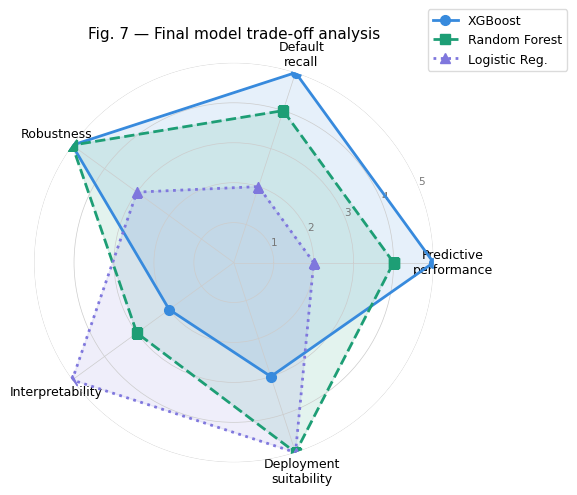

In [6]:
# ── Figure 7: Radar chart ─────────────────────────────────────────
categories = ['Predictive\nperformance', 'Default\nrecall',
              'Robustness', 'Interpretability', 'Deployment\nsuitability']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

# Ordinal scores 1–5 derived from experimental evidence
xgb_s = [5,5,5,2,3] + [5]
rf_s  = [4,4,5,3,5] + [4]
lr_s  = [2,2,3,5,5] + [2]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for scores, color, label, ls in [
    (xgb_s, '#378ADD', 'XGBoost',       'o-'),
    (rf_s,  '#1D9E75', 'Random Forest', 's--'),
    (lr_s,  '#7F77DD', 'Logistic Reg.', '^:'),
]:
    ax.plot(angles, scores, ls, color=color, lw=2, ms=7, label=label)
    ax.fill(angles, scores, alpha=0.12, color=color)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0,5); ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=7.5, color='#777')
ax.grid(color='#cccccc', linewidth=0.5); ax.spines['polar'].set_visible(False)
ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.35,1.15), framealpha=0.7)
ax.set_title('Fig. 7 — Final model trade-off analysis', fontsize=11, pad=18)
plt.tight_layout()
plt.savefig('fig7_radar.png', dpi=180, bbox_inches='tight')
plt.show()


In [7]:
# ── Fairness check: FNR by demographic group ─────────────────────
# False Negative Rate = predicted repaid but actually defaulted
# High FNR in a group = model under-flags defaults in that group

test_idx = X_test.index
df_test  = df.loc[test_idx].copy()
df_test['y_pred'] = xgb.predict(X_test_sc)
df_test['y_true'] = y_test.values

print("=== False Negative Rate by employment_status ===")
defaults = df_test[df_test['y_true'] == 0]
for grp, sub in defaults.groupby('employment_status'):
    fnr = (sub['y_pred'] == 1).mean()
    print(f"  {grp:18s}: FNR = {fnr:.3f}  (n={len(sub)})")

print("\n=== Default rate by education_level ===")
for grp, sub in df_test.groupby('education_level'):
    dr = (sub['y_true'] == 0).mean()
    print(f"  {grp:18s}: default rate = {dr:.3f}  (n={len(sub)})")


=== False Negative Rate by employment_status ===
  Employed          : FNR = 0.976  (n=289)
  Retired           : FNR = 1.000  (n=1)
  Self-employed     : FNR = 0.971  (n=69)
  Student           : FNR = 0.024  (n=85)
  Unemployed        : FNR = 0.003  (n=356)

=== Default rate by education_level ===
  Bachelor's        : default rate = 0.214  (n=1561)
  High School       : default rate = 0.189  (n=1249)
  Master's          : default rate = 0.213  (n=726)
  Other             : default rate = 0.191  (n=314)
  PhD               : default rate = 0.100  (n=150)


## Final Recommendation

| Use case | Recommended model |
|---|---|
| Maximum predictive performance | **XGBoost** |
| Production deployment (balanced) | **Random Forest** |
| Regulatory reporting / audit | **Logistic Regression** |

**Fairness note:** Review the FNR output above. Any demographic group with a substantially higher FNR is being under-flagged as risky — the model is giving them a false sense of creditworthiness. This must be disclosed alongside performance metrics in any real deployment.
